In [1]:
# import the environmentation path to make sure the right version of library
import sys
directory = '/home/students/acct1002_02/anaconda3/envs/tf_gpu/lib/python3.8/site-packages'
sys.path.insert(0, directory)

In [2]:
#use CPU for IQA as CUDA in GPU is not compatible with the python version
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"

# Import library

In [12]:
import imquality.brisque as brisque
import PIL.Image
import pandas as pd
import numpy as np
from tqdm import tqdm
from PIL import ImageFile
from tensorflow.keras.preprocessing import image
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [5]:
from skimage.metrics import peak_signal_noise_ratio as PSNR

# Load Data, preprocess

In [6]:
disease_img = {'Atelectasis': [],
                 'Cardiomegaly': [],
                 'Effusion': [],
                 'Infiltration': [],
                 'Mass': [],
                 'Nodule': [],
                 'Pneumonia': [],
                 'Pneumothorax': [],
                 'Consolidation': [],
                 'Edema': [],
                 'Emphysema': [],
                 'Fibrosis': [],
                 'Pleural_Thickening': [],
                 'Hernia': [],
                 'No Finding':[]}

In [7]:
disease_class = {'Atelectasis': 1,
                 'Cardiomegaly': 2,
                 'Effusion': 3,
                 'Infiltration': 4,
                 'Mass': 5,
                 'Nodule': 6,
                 'Pneumonia': 7,
                 'Pneumothorax': 8,
                 'Consolidation': 9,
                 'Edema': 10,
                 'Emphysema': 11,
                 'Fibrosis': 12,
                 'Pleural_Thickening': 13,
                 'Hernia': 14,
                 'No Finding': 15}

disease_rev = {v: k for k, v in disease_class.items()}

In [8]:
data_ref = pd.read_csv("Data_Entry.csv")
pd.options.mode.chained_assignment = None        #ignore the SettingWithCopyWarning
img_names = []

for i in tqdm(range(len(data_ref))):
    #print(i)
    if "|" not in data_ref['Finding Labels'][i]:
        disease_img[data_ref['Finding Labels'][i]].append(data_ref['Image Index'][i])
        img_names.append(data_ref['Image Index'][i])

100%|██████████| 112120/112120 [00:04<00:00, 24403.21it/s]


# PSNR

In [22]:
# PSNR (CycleGAN, Noise, Original)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

quality = pd.DataFrame(columns = ['Noise VS Original', 'cycleGAN VS Original'])

for i in tqdm(range(0, len(img_names))):
    name = img_names[i]
    ori = image.load_img('CY1400/images/'+name,target_size=(112,112,3))
    ori = image.img_to_array(ori)
    
    gan = image.load_img('CY1400/GAN/GG'+name,target_size=(112,112,3))
    gan = image.img_to_array(gan)
    gan_score = PSNR(ori, gan, data_range = 255)
    
    noi = image.load_img('CY1400/Noise/N'+name,target_size=(112,112,3))
    noi = image.img_to_array(noi)
    noi_score = PSNR(noi, gan, data_range = 255)
    quality = quality.append({'Noise VS Original':noi_score, 'cycleGAN VS Original': gan_score}, ignore_index=True)

quality.to_csv('IQA_PSNR.csv')

100%|██████████| 91324/91324 [53:57<00:00, 28.21it/s]  


In [28]:
bin_values = np.arange(start=0, stop=25, step=1)

<AxesSubplot:ylabel='Frequency'>

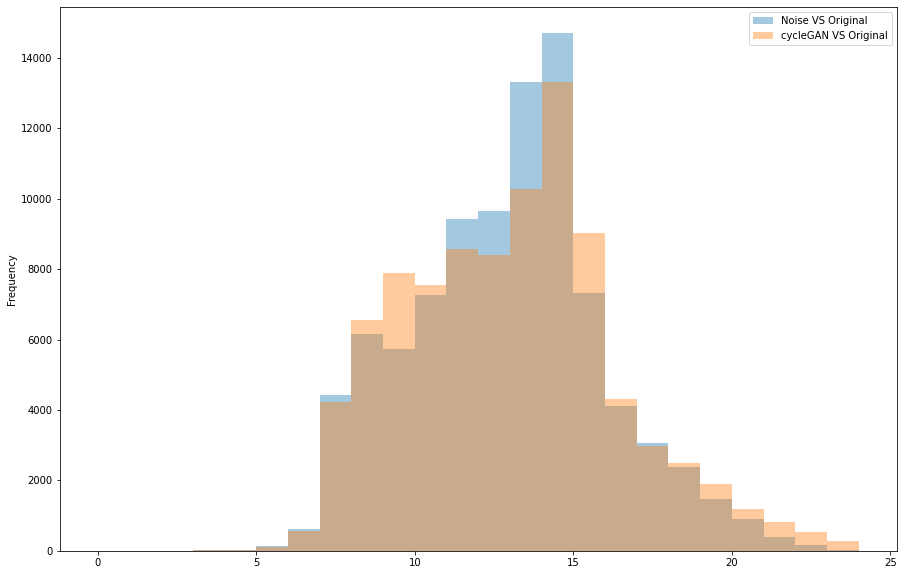

In [30]:
original = quality['Noise VS Original']
original.plot(kind = 'hist', bins=bin_values, figsize=[15,10], alpha=.4, legend = 'Ture')
noise = quality['cycleGAN VS Original']
noise.plot(kind = 'hist', bins=bin_values, figsize=[15,10],alpha=.4, legend = 'Ture')
#gan = quality['GAN']
#gan.plot(kind = 'hist', bins=bin_values, figsize=[15,10],alpha=.4, legend = 'Ture')

# BRISQUE

In [ ]:
# BRISQUE (DCGAN, Original, Noise)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

quality = pd.DataFrame(columns = ['Img_Name','Original', 'DCGAN', 'Noise'])

for i in tqdm(range(len(img_names))):
    name = img_names[i]
    ori = PIL.Image.open('CY1400/images/'+name).resize((112,112))
    ori_score = brisque.score(ori)
    
    gan = PIL.Image.open('CY1400/GAN/G'+name)
    gan_score = brisque.score(gan)
    
    noi = PIL.Image.open('CY1400/Noise/N'+name)
    noi_score = brisque.score(noi)
    quality = quality.append({'Img_Name': name, 'Original': ori_score, 'DCGAN': gan_score, 'Noise': noi_score}, ignore_index=True)

quality.to_csv('IQA_BRISQUE.csv')

In [ ]:
bin_values = np.arange(start=-50, stop=200, step=10)

original = quality['Original']
original.plot(kind = 'hist', bins=bin_values, figsize=[15,10], legend = 'Ture')
noise = quality['Noise']
noise.plot(kind = 'hist', bins=bin_values, figsize=[15,10],alpha=.4, legend = 'Ture')
gan = quality['DCGAN']
gan.plot(kind = 'hist', bins=bin_values, figsize=[15,10],alpha=.4, legend = 'Ture')